# 03 — Ablaciones VQSA

Ablaciones alineadas con el paper: sin codebook, replace, add, concat sin self-attention y VQSA completo.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import ABLATION_SPECS, ablation_config, resolve_data_dir
from dememte.data import build_loaders, seed_everything
from dememte.models import make_dememte_variant
from dememte.training import train_dememte_vqsa
from dememte.evaluation import evaluate_dememte_suite, signal_curve_rows
from dememte.io import load_checkpoint, save_checkpoint, write_json, write_csv, ensure_dir

device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '03_ablations' / 'out')
RUN_TRAINING = True

data_dir = resolve_data_dir(ablation_config('vqsa_full'))
seed_everything(42)

## Datos (compartidos entre todas las variantes)

In [3]:
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=data_dir,
    batch_size=16,
    num_workers=2,
    val_ratio=0.2,
    split_seed=42,
    protocol='historical_trainval_resplit',
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Variantes VQSA

In [4]:
VARIANTS = list(ABLATION_SPECS.keys())
for name in VARIANTS:
    print(f'  - {name:42s}  ::  {ABLATION_SPECS[name]["label"]}')

  - vqsa_full                                   ::  VQSA full
  - no_codebook                                 ::  Ablation no codebook
  - replace                                     ::  Ablation VQ replace fusion
  - add                                         ::  Ablation VQ add fusion
  - concat_no_sa                                ::  Ablation concat without self-attention


## Loop de entrenamiento/carga + evaluación

In [5]:
def checkpoint_for_variant(variant):
    return OUT / variant / 'best.pt'

all_summaries = []
all_curves = []

for variant in VARIANTS:
    print(f'=== {variant} ===')
    vdir = ensure_dir(OUT / variant)
    cfg = ablation_config(variant)
    cfg.data_dir = data_dir
    seed_everything(cfg.seed)
    model = make_dememte_variant(cfg, device=device)
    ckpt_path = checkpoint_for_variant(variant)

    if RUN_TRAINING:
        model, best_acc = train_dememte_vqsa(model, tr_loader, va_loader, cfg, device)
        save_checkpoint(model, ckpt_path, extra={'best_val': best_acc, 'config': cfg})
        print('saved checkpoint:', ckpt_path, '| best_val:', best_acc)
    else:
        if not ckpt_path.exists():
            raise FileNotFoundError(f'Missing VQSA ablation checkpoint for {variant}: {ckpt_path}. Set RUN_TRAINING=True.')
        payload = load_checkpoint(model, ckpt_path, device=device, strict=True)
        print('loaded checkpoint:', ckpt_path, '| best_val:', payload.get('best_val'))

    metrics = evaluate_dememte_suite(model, te_loader, device=device)
    clean_record = metrics.pop('clean_record'); corrupt_records = metrics.pop('corruption_records')
    curve_rows = signal_curve_rows(variant, ABLATION_SPECS[variant]['label'], clean_record, corrupt_records)

    summary = {k: v for k, v in metrics.items() if isinstance(v, (int, float, bool))}
    summary.update({'variant': variant, 'label': ABLATION_SPECS[variant]['label'], 'checkpoint': str(ckpt_path)})
    write_json(summary, vdir / 'metrics.json')
    write_csv(curve_rows, vdir / 'signal_curves.csv')
    all_summaries.append(summary)
    all_curves.extend(curve_rows)

summary_df = pd.DataFrame(all_summaries)
write_csv(all_summaries, OUT / 'ablation_results.csv')
write_csv(all_curves, OUT / 'ablation_curves.csv')
summary_df

=== vqsa_full ===
[VQSA 01] tr_loss=4.5407 tr_acc=0.1360 val_loss=3.3285 val_acc=0.3676 val_vq=0.6731
[VQSA 02] tr_loss=3.0232 tr_acc=0.3860 val_loss=2.3458 val_acc=0.5564 val_vq=0.6698
[VQSA 03] tr_loss=2.3647 tr_acc=0.5309 val_loss=2.0401 val_acc=0.6176 val_vq=0.6509
[VQSA 04] tr_loss=2.0492 tr_acc=0.5965 val_loss=1.8819 val_acc=0.6544 val_vq=0.6164
[VQSA 05] tr_loss=1.7966 tr_acc=0.6670 val_loss=1.8217 val_acc=0.6814 val_vq=0.6098
[VQSA 06] tr_loss=1.5883 tr_acc=0.7004 val_loss=1.7177 val_acc=0.6961 val_vq=0.5747
[VQSA 07] tr_loss=1.5931 tr_acc=0.6958 val_loss=1.5943 val_acc=0.7402 val_vq=0.5811
[VQSA 08] tr_loss=1.4914 tr_acc=0.7240 val_loss=1.6325 val_acc=0.7426 val_vq=0.5437
[VQSA 09] tr_loss=1.3661 tr_acc=0.7619 val_loss=1.6272 val_acc=0.7034 val_vq=0.5369
[VQSA 10] tr_loss=1.2796 tr_acc=0.7969 val_loss=1.5085 val_acc=0.7525 val_vq=0.5327
saved checkpoint: /home/nakato/projects/Dememte/notebooks/03_ablations/out/vqsa_full/best.pt | best_val: 0.7524509803921569
=== no_codebook ==

,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur,ece_clean,ece_corrupt_avg,nll_clean,nll_corrupt_avg,...,dq_mean_corrupt_avg,assignment_entropy_clean,assignment_entropy_corrupt_avg,codebook_perplexity_clean,codebook_perplexity_corrupt_avg,attention_entropy_clean,attention_entropy_corrupt_avg,variant,label,checkpoint
0,0.736055,0.495704,0.357131,0.340543,0.624112,0.661029,0.043293,0.080977,0.975917,1.971522,...,0.463703,0.162135,0.099998,3.878576,2.575385,0.520541,0.525122,vqsa_full,VQSA full,/home/nakato/projects/Dememte/notebooks/03_abl...
1,0.743210,0.490988,0.355505,0.337887,0.621998,0.648561,0.023411,0.061724,0.999664,2.046086,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,no_codebook,Ablation no codebook,/home/nakato/projects/Dememte/notebooks/03_abl...
2,0.009432,0.009432,0.009432,0.009432,0.009432,0.009432,0.000844,0.000844,4.626314,4.626314,...,0.440686,0.794865,0.734441,291.102051,204.143130,0.000000,0.000000,replace,Ablation VQ replace fusion,/home/nakato/projects/Dememte/notebooks/03_abl...
3,0.798666,0.556689,0.408576,0.407980,0.697783,0.712419,0.223416,0.173111,0.947679,1.847931,...,0.604325,0.048748,0.112201,1.514296,2.836843,0.000000,0.000000,add,Ablation VQ add fusion,/home/nakato/projects/Dememte/notebooks/03_abl...
4,0.746951,0.507223,0.367214,0.361468,0.646447,0.653765,0.269456,0.199702,1.220264,2.107912,...,0.591029,0.019993,0.102464,1.180716,2.974772,0.000000,0.000000,concat_no_sa,Ablation concat without self-attention,/home/nakato/projects/Dememte/notebooks/03_abl...


## Tabla comparativa (clean vs corrupt)

In [6]:
cols = ['variant', 'clean_acc', 'corrupt_acc_avg', 'corrupt_acc_gaussian_noise', 'corrupt_acc_pixel_mask', 'corrupt_acc_cutout', 'corrupt_acc_blur']
cols = [c for c in cols if c in summary_df.columns]
ranked = summary_df[cols].sort_values('corrupt_acc_avg', ascending=False)
ranked.to_markdown(OUT / 'ablation_summary.md', index=False) if hasattr(ranked, 'to_markdown') else ranked.to_csv(OUT / 'ablation_summary.md', sep='|', index=False)
ranked

,variant,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur
3,add,0.798666,0.556689,0.408576,0.407980,0.697783,0.712419
4,concat_no_sa,0.746951,0.507223,0.367214,0.361468,0.646447,0.653765
0,vqsa_full,0.736055,0.495704,0.357131,0.340543,0.624112,0.661029
1,no_codebook,0.743210,0.490988,0.355505,0.337887,0.621998,0.648561
2,replace,0.009432,0.009432,0.009432,0.009432,0.009432,0.009432


## Comparativa visual clean vs corrupt

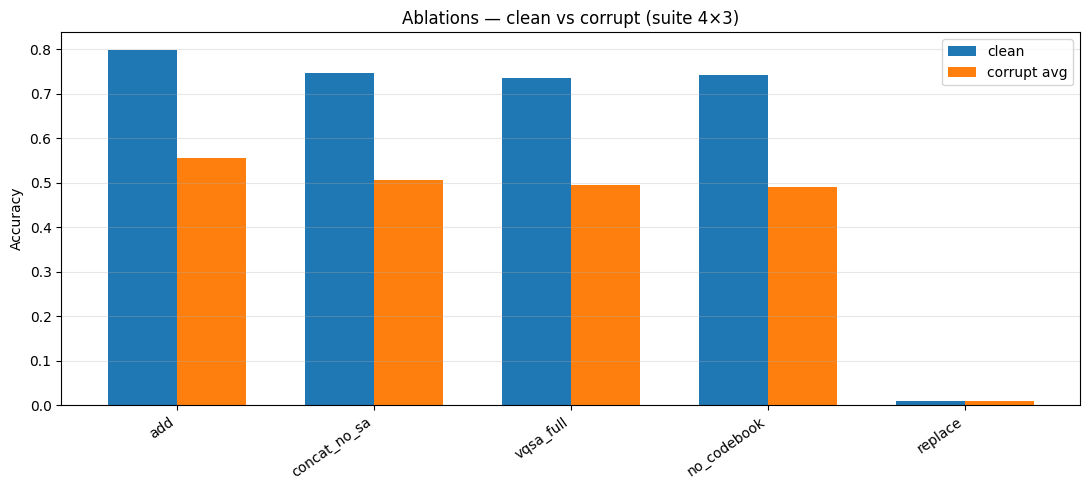

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ranked))
width = 0.35
ax.bar(x - width/2, ranked['clean_acc'], width, label='clean')
ax.bar(x + width/2, ranked['corrupt_acc_avg'], width, label='corrupt avg')
ax.set_xticks(x); ax.set_xticklabels(ranked['variant'], rotation=35, ha='right')
ax.set_ylabel('Accuracy'); ax.set_title('Ablations — clean vs corrupt (suite 4×3)')
ax.grid(alpha=0.3, axis='y'); ax.legend()
ensure_dir(OUT / 'plots')
fig.savefig(OUT / 'plots' / 'ablations_clean_vs_corrupt.png', dpi=120, bbox_inches='tight')
plt.tight_layout(); plt.show()